In [1]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

import os
import glob

from datetime import datetime

import warnings
warnings.filterwarnings("ignore")

In [2]:
plt.style.use("ggplot")
sns.set_palette("Set2")

In [5]:
data_path = r"C:\Users\Anamey\Downloads\Ford_GoBike_EDA\data"
csv_files = glob.glob(os.path.join(data_path, "*.csv"))

print("Number of CSV files found:", len(csv_files))

Number of CSV files found: 12


In [6]:
for file in csv_files:
    print(os.path.basename(file))

201801-fordgobike-tripdata.csv
201802-fordgobike-tripdata.csv
201803-fordgobike-tripdata.csv
201804-fordgobike-tripdata.csv
201805-fordgobike-tripdata.csv
201806-fordgobike-tripdata.csv
201807-fordgobike-tripdata.csv
201808-fordgobike-tripdata.csv
201809-fordgobike-tripdata.csv
201810-fordgobike-tripdata.csv
201811-fordgobike-tripdata.csv
201812-fordgobike-tripdata.csv


In [7]:
df_list = []

for file in csv_files:
    df = pd.read_csv(file)
    df_list.append(df)

In [8]:
bike = pd.concat(df_list, ignore_index=True)

In [9]:
bike.shape

(1863721, 16)

In [10]:
bike.head()

,duration_sec,start_time,end_time,start_station_id,start_station_name,start_station_latitude,start_station_longitude,end_station_id,end_station_name,end_station_latitude,end_station_longitude,bike_id,user_type,member_birth_year,member_gender,bike_share_for_all_trip
0,75284,2018-01-31 22:52:35.2390,2018-02-01 19:47:19.8240,120.0,Mission Dolores Park,37.761420,-122.426435,285.0,Webster St at O'Farrell St,37.783521,-122.431158,2765,Subscriber,1986.0,Male,No
1,85422,2018-01-31 16:13:34.3510,2018-02-01 15:57:17.3100,15.0,San Francisco Ferry Building (Harry Bridges Pl...,37.795392,-122.394203,15.0,San Francisco Ferry Building (Harry Bridges Pl...,37.795392,-122.394203,2815,Customer,NaN,NaN,No
2,71576,2018-01-31 14:23:55.8890,2018-02-01 10:16:52.1160,304.0,Jackson St at 5th St,37.348759,-121.894798,296.0,5th St at Virginia St,37.325998,-121.877120,3039,Customer,1996.0,Male,No
3,61076,2018-01-31 14:53:23.5620,2018-02-01 07:51:20.5000,75.0,Market St at Franklin St,37.773793,-122.421239,47.0,4th St at Harrison St,37.780955,-122.399749,321,Customer,NaN,NaN,No
4,39966,2018-01-31 19:52:24.6670,2018-02-01 06:58:31.0530,74.0,Laguna St at Hayes St,37.776435,-122.426244,19.0,Post St at Kearny St,37.788975,-122.403452,617,Subscriber,1991.0,Male,No


In [11]:
bike.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1863721 entries, 0 to 1863720
Data columns (total 16 columns):
 #   Column                   Dtype  
---  ------                   -----  
 0   duration_sec             int64  
 1   start_time               object 
 2   end_time                 object 
 3   start_station_id         float64
 4   start_station_name       object 
 5   start_station_latitude   float64
 6   start_station_longitude  float64
 7   end_station_id           float64
 8   end_station_name         object 
 9   end_station_latitude     float64
 10  end_station_longitude    float64
 11  bike_id                  int64  
 12  user_type                object 
 13  member_birth_year        float64
 14  member_gender            object 
 15  bike_share_for_all_trip  object 
dtypes: float64(7), int64(2), object(7)
memory usage: 227.5+ MB


In [12]:
bike.describe()

,duration_sec,start_station_id,start_station_latitude,start_station_longitude,end_station_id,end_station_latitude,end_station_longitude,bike_id,member_birth_year
count,1.863721e+06,1.851950e+06,1.863721e+06,1.863721e+06,1.851950e+06,1.863721e+06,1.863721e+06,1.863721e+06,1.753003e+06
mean,8.573026e+02,1.196744e+02,3.776678e+01,-1.223492e+02,1.181730e+02,3.776690e+01,-1.223487e+02,2.296851e+03,1.983088e+03
std,2.370379e+03,1.003976e+02,1.057689e-01,1.654634e-01,1.004403e+02,1.056483e-01,1.650597e-01,1.287733e+03,1.044289e+01
min,6.100000e+01,3.000000e+00,3.726331e+01,-1.224737e+02,3.000000e+00,3.726331e+01,-1.224737e+02,1.100000e+01,1.881000e+03
25%,3.500000e+02,3.300000e+01,3.777106e+01,-1.224114e+02,3.000000e+01,3.777106e+01,-1.224094e+02,1.225000e+03,1.978000e+03
50%,5.560000e+02,8.900000e+01,3.778107e+01,-1.223974e+02,8.800000e+01,3.778127e+01,-1.223971e+02,2.338000e+03,1.985000e+03
75%,8.720000e+02,1.860000e+02,3.779625e+01,-1.222865e+02,1.830000e+02,3.779728e+01,-1.222894e+02,3.333000e+03,1.991000e+03
max,8.636600e+04,3.810000e+02,4.551000e+01,-7.357000e+01,3.810000e+02,4.551000e+01,-7.357000e+01,6.234000e+03,2.000000e+03


In [13]:
bike.describe(include='object')

,start_time,end_time,start_station_name,end_station_name,user_type,member_gender,bike_share_for_all_trip
count,1863721,1863721,1851950,1851950,1863721,1753354,1863721
unique,1863584,1863610,348,348,2,3,2
top,2018-12-13 18:14:08.1500,2018-12-26 16:54:27.2130,San Francisco Ferry Building (Harry Bridges Pl...,San Francisco Caltrain Station 2 (Townsend St...,Subscriber,Male,No
freq,2,2,38461,50000,1583554,1288085,1701386


In [14]:
bike.columns

Index(['duration_sec', 'start_time', 'end_time', 'start_station_id',
       'start_station_name', 'start_station_latitude',
       'start_station_longitude', 'end_station_id', 'end_station_name',
       'end_station_latitude', 'end_station_longitude', 'bike_id', 'user_type',
       'member_birth_year', 'member_gender', 'bike_share_for_all_trip'],
      dtype='object')

In [15]:
bike.isnull().sum()

duration_sec                    0
start_time                      0
end_time                        0
start_station_id            11771
start_station_name          11771
start_station_latitude          0
start_station_longitude         0
end_station_id              11771
end_station_name            11771
end_station_latitude            0
end_station_longitude           0
bike_id                         0
user_type                       0
member_birth_year          110718
member_gender              110367
bike_share_for_all_trip         0
dtype: int64

In [16]:
bike.duplicated().sum()

np.int64(0)

In [18]:
bike.to_csv("bike_combined.csv", index=False)

In [21]:
bike_clean = bike.copy()

In [22]:
bike_clean.dtypes

duration_sec                 int64
start_time                  object
end_time                    object
start_station_id           float64
start_station_name          object
start_station_latitude     float64
start_station_longitude    float64
end_station_id             float64
end_station_name            object
end_station_latitude       float64
end_station_longitude      float64
bike_id                      int64
user_type                   object
member_birth_year          float64
member_gender               object
bike_share_for_all_trip     object
dtype: object

In [23]:
bike_clean["start_time"] = pd.to_datetime(bike_clean["start_time"])

bike_clean["end_time"] = pd.to_datetime(bike_clean["end_time"])

In [24]:
bike_clean.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1863721 entries, 0 to 1863720
Data columns (total 16 columns):
 #   Column                   Dtype         
---  ------                   -----         
 0   duration_sec             int64         
 1   start_time               datetime64[ns]
 2   end_time                 datetime64[ns]
 3   start_station_id         float64       
 4   start_station_name       object        
 5   start_station_latitude   float64       
 6   start_station_longitude  float64       
 7   end_station_id           float64       
 8   end_station_name         object        
 9   end_station_latitude     float64       
 10  end_station_longitude    float64       
 11  bike_id                  int64         
 12  user_type                object        
 13  member_birth_year        float64       
 14  member_gender            object        
 15  bike_share_for_all_trip  object        
dtypes: datetime64[ns](2), float64(7), int64(2), object(5)
memory usage: 227.

In [25]:
missing = bike_clean.isnull().sum().sort_values(ascending=False)

missing_percent = (
    bike_clean.isnull().sum() /
    len(bike_clean)
    *100
).sort_values(ascending=False)

missing_table = pd.DataFrame({
    "Missing Values": missing,
    "Percentage": missing_percent.round(2)
})

missing_table

,Missing Values,Percentage
member_birth_year,110718,5.94
member_gender,110367,5.92
start_station_id,11771,0.63
start_station_name,11771,0.63
end_station_id,11771,0.63
end_station_name,11771,0.63
duration_sec,0,0.00
start_time,0,0.00
end_time,0,0.00
start_station_latitude,0,0.00


In [26]:
bike_clean = bike_clean.dropna(
    subset=[
        "start_station_id",
        "start_station_name",
        "end_station_id",
        "end_station_name"
    ]
)

In [27]:
bike_clean.isnull().sum()

duration_sec                    0
start_time                      0
end_time                        0
start_station_id                0
start_station_name              0
start_station_latitude          0
start_station_longitude         0
end_station_id                  0
end_station_name                0
end_station_latitude            0
end_station_longitude           0
bike_id                         0
user_type                       0
member_birth_year          110394
member_gender              110043
bike_share_for_all_trip         0
dtype: int64

In [28]:
bike_clean = bike_clean.dropna(
    subset=[
        "member_birth_year",
        "member_gender"
    ]
)

bike_clean.isnull().sum()

duration_sec               0
start_time                 0
end_time                   0
start_station_id           0
start_station_name         0
start_station_latitude     0
start_station_longitude    0
end_station_id             0
end_station_name           0
end_station_latitude       0
end_station_longitude      0
bike_id                    0
user_type                  0
member_birth_year          0
member_gender              0
bike_share_for_all_trip    0
dtype: int64

In [29]:
bike_clean.shape

(1741556, 16)

In [30]:
bike_clean["duration_sec"].describe()

count    1.741556e+06
mean     7.728624e+02
std      1.943048e+03
min      6.100000e+01
25%      3.440000e+02
50%      5.430000e+02
75%      8.390000e+02
max      8.628100e+04
Name: duration_sec, dtype: float64

In [31]:
bike_clean["member_birth_year"].describe()

count    1.741556e+06
mean     1.983061e+03
std      1.045133e+01
min      1.881000e+03
25%      1.978000e+03
50%      1.985000e+03
75%      1.991000e+03
max      2.000000e+03
Name: member_birth_year, dtype: float64

In [32]:
bike_clean["age"] = 2018 - bike_clean["member_birth_year"]

In [33]:
bike_clean["age"].describe()

count    1.741556e+06
mean     3.493921e+01
std      1.045133e+01
min      1.800000e+01
25%      2.700000e+01
50%      3.300000e+01
75%      4.000000e+01
max      1.370000e+02
Name: age, dtype: float64

In [34]:
bike_clean = bike_clean[
    (bike_clean["age"] >= 16) &
    (bike_clean["age"] <= 80)
]

In [35]:
bike_clean["age"].describe()

count    1.739129e+06
mean     3.484818e+01
std      1.015435e+01
min      1.800000e+01
25%      2.700000e+01
50%      3.300000e+01
75%      4.000000e+01
max      8.000000e+01
Name: age, dtype: float64

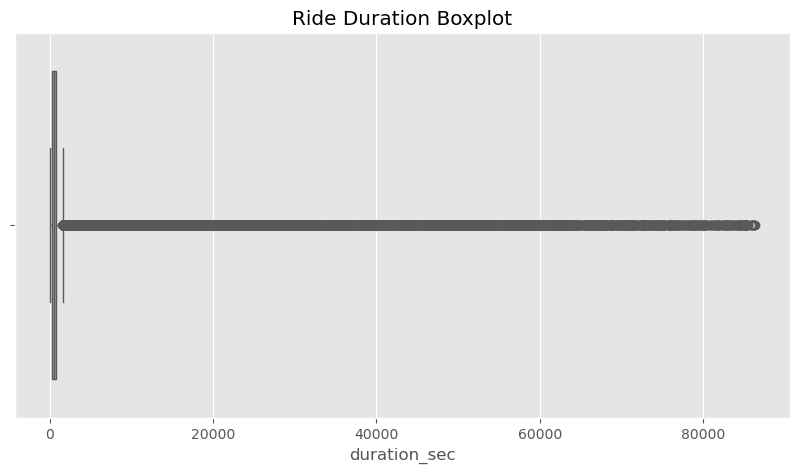

In [36]:
plt.figure(figsize=(10,5))
sns.boxplot(x=bike_clean["duration_sec"])
plt.title("Ride Duration Boxplot")
plt.show()

In [37]:
bike_clean.to_csv("bike_clean.csv", index=False)

In [38]:
bike_clean.shape

bike_clean["duration_sec"].describe()

bike_clean["age"].describe()

count    1.739129e+06
mean     3.484818e+01
std      1.015435e+01
min      1.800000e+01
25%      2.700000e+01
50%      3.300000e+01
75%      4.000000e+01
max      8.000000e+01
Name: age, dtype: float64

In [39]:
bike_clean["duration_sec"].describe()

count    1.739129e+06
mean     7.728895e+02
std      1.943328e+03
min      6.100000e+01
25%      3.440000e+02
50%      5.430000e+02
75%      8.390000e+02
max      8.628100e+04
Name: duration_sec, dtype: float64

In [40]:
bike_clean.to_csv(
    r"C:\Users\Anamey\Downloads\Ford_GoBike_EDA\bike_clean.csv",
    index=False
)

In [41]:
bike_clean["duration_min"] = bike_clean["duration_sec"] / 60

In [42]:
bike_clean["year"] = bike_clean["start_time"].dt.year

In [43]:
bike_clean["month"] = bike_clean["start_time"].dt.month

In [44]:
bike_clean["month_name"] = bike_clean["start_time"].dt.month_name()

In [45]:
bike_clean["day_of_week"] = bike_clean["start_time"].dt.day_name()

In [46]:
bike_clean["hour"] = bike_clean["start_time"].dt.hour

In [47]:
bike_clean["date"] = bike_clean["start_time"].dt.date

In [48]:
bike_clean["quarter"] = bike_clean["start_time"].dt.quarter

In [49]:
bike_clean["is_weekend"] = bike_clean["day_of_week"].isin(
    ["Saturday", "Sunday"]
)

In [67]:
bins = [18, 25, 35, 45, 55, 65, 81]
labels = ["18-24", "25-34", "35-44", "45-54", "55-64", "65-80"]

bike_clean["age_group"] = pd.cut(
    bike_clean["age"],
    bins=bins,
    labels=labels,
    right=False
)

In [50]:
def time_of_day(hour):
    if 5 <= hour < 12:
        return "Morning"
    elif 12 <= hour < 17:
        return "Afternoon"
    elif 17 <= hour < 21:
        return "Evening"
    else:
        return "Night"

bike_clean["time_of_day"] = bike_clean["hour"].apply(time_of_day)

In [51]:
bike_clean.head()

,duration_sec,start_time,end_time,start_station_id,start_station_name,start_station_latitude,start_station_longitude,end_station_id,end_station_name,end_station_latitude,...,duration_min,year,month,month_name,day_of_week,hour,date,quarter,is_weekend,time_of_day
0,75284,2018-01-31 22:52:35.239,2018-02-01 19:47:19.824,120.0,Mission Dolores Park,37.761420,-122.426435,285.0,Webster St at O'Farrell St,37.783521,...,1254.733333,2018,1,January,Wednesday,22,2018-01-31,1,False,Night
2,71576,2018-01-31 14:23:55.889,2018-02-01 10:16:52.116,304.0,Jackson St at 5th St,37.348759,-121.894798,296.0,5th St at Virginia St,37.325998,...,1192.933333,2018,1,January,Wednesday,14,2018-01-31,1,False,Afternoon
4,39966,2018-01-31 19:52:24.667,2018-02-01 06:58:31.053,74.0,Laguna St at Hayes St,37.776435,-122.426244,19.0,Post St at Kearny St,37.788975,...,666.100000,2018,1,January,Wednesday,19,2018-01-31,1,False,Evening
6,453,2018-01-31 23:53:53.632,2018-02-01 00:01:26.805,110.0,17th & Folsom Street Park (17th St at Folsom St),37.763708,-122.415204,134.0,Valencia St at 24th St,37.752428,...,7.550000,2018,1,January,Wednesday,23,2018-01-31,1,False,Night
7,180,2018-01-31 23:52:09.903,2018-01-31 23:55:10.807,81.0,Berry St at 4th St,37.775880,-122.393170,93.0,4th St at Mission Bay Blvd S,37.770407,...,3.000000,2018,1,January,Wednesday,23,2018-01-31,1,False,Night


In [52]:
bike_clean.columns

Index(['duration_sec', 'start_time', 'end_time', 'start_station_id',
       'start_station_name', 'start_station_latitude',
       'start_station_longitude', 'end_station_id', 'end_station_name',
       'end_station_latitude', 'end_station_longitude', 'bike_id', 'user_type',
       'member_birth_year', 'member_gender', 'bike_share_for_all_trip', 'age',
       'duration_min', 'year', 'month', 'month_name', 'day_of_week', 'hour',
       'date', 'quarter', 'is_weekend', 'time_of_day'],
      dtype='object')

In [53]:
#univariate analysis
bike_clean["duration_min"].describe()

count    1.739129e+06
mean     1.288149e+01
std      3.238880e+01
min      1.016667e+00
25%      5.733333e+00
50%      9.050000e+00
75%      1.398333e+01
max      1.438017e+03
Name: duration_min, dtype: float64

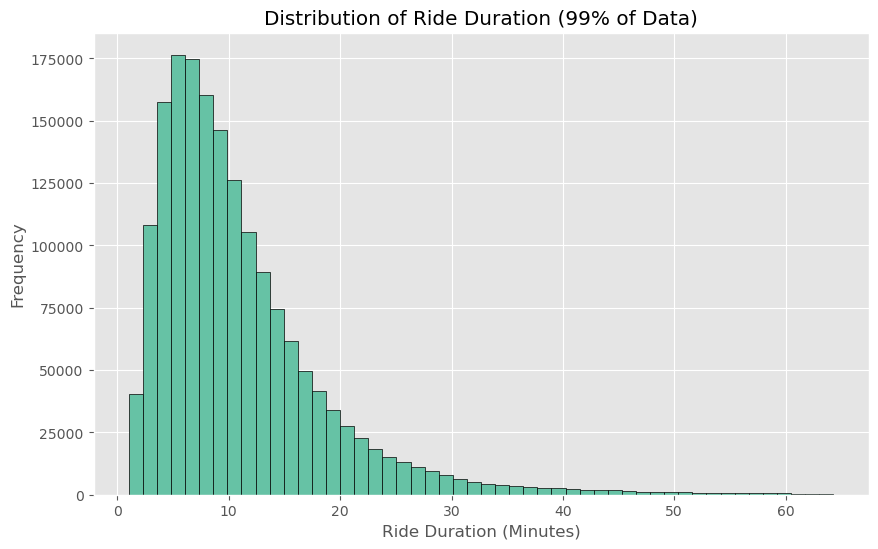

In [57]:
plt.figure(figsize=(10,6))

upper_limit = bike_clean["duration_min"].quantile(0.99)

plt.hist(
    bike_clean[bike_clean["duration_min"] <= upper_limit]["duration_min"],
    bins=50,
    edgecolor="black"
)

plt.title("Distribution of Ride Duration (99% of Data)")
plt.xlabel("Ride Duration (Minutes)")
plt.ylabel("Frequency")

plt.show()

In [58]:
bike_clean["user_type"].value_counts()

user_type
Subscriber    1540093
Customer       199036
Name: count, dtype: int64

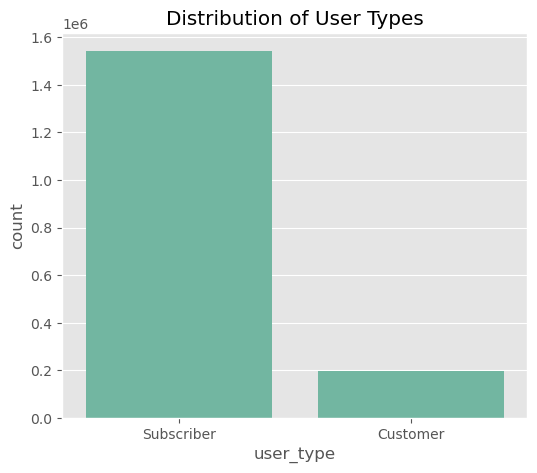

In [59]:
plt.figure(figsize=(6,5))

sns.countplot(
    data=bike_clean,
    x="user_type"
)

plt.title("Distribution of User Types")

plt.show()

In [60]:
bike_clean["user_type"].value_counts(normalize=True)*100

user_type
Subscriber    88.555421
Customer      11.444579
Name: proportion, dtype: float64

In [61]:
bike_clean["member_gender"].value_counts()

member_gender
Male      1277930
Female     434566
Other       26633
Name: count, dtype: int64

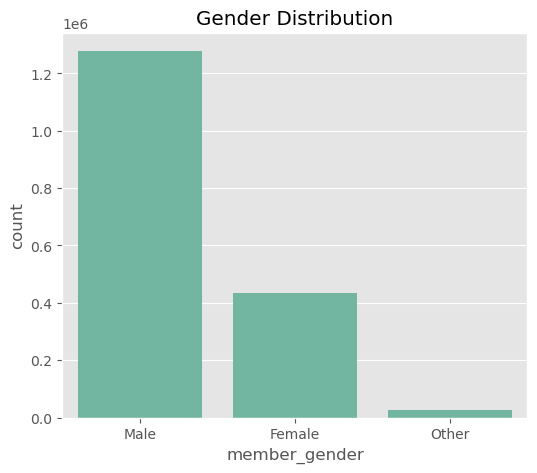

In [62]:
plt.figure(figsize=(6,5))

sns.countplot(
    data=bike_clean,
    x="member_gender"
)

plt.title("Gender Distribution")

plt.show()

In [63]:
bike_clean["member_gender"].value_counts(normalize=True)*100

member_gender
Male      73.481036
Female    24.987566
Other      1.531399
Name: proportion, dtype: float64

In [64]:
bike_clean["age"].describe()

count    1.739129e+06
mean     3.484818e+01
std      1.015435e+01
min      1.800000e+01
25%      2.700000e+01
50%      3.300000e+01
75%      4.000000e+01
max      8.000000e+01
Name: age, dtype: float64

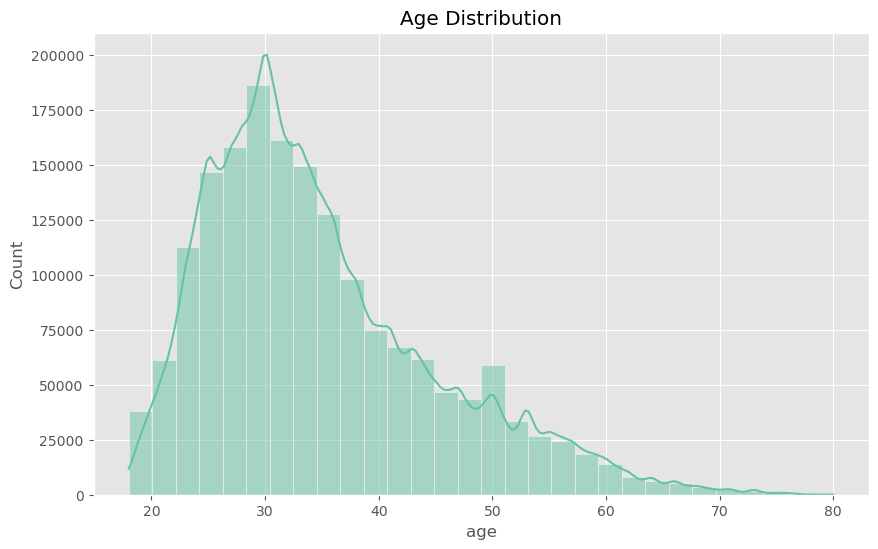

In [65]:
plt.figure(figsize=(10,6))

sns.histplot(
    bike_clean["age"],
    bins=30,
    kde=True
)

plt.title("Age Distribution")

plt.show()

In [68]:
bike_clean["age_group"].value_counts()

age_group
25-34    802358
35-44    429579
18-24    211661
45-54    195650
55-64     83885
65-80     15996
Name: count, dtype: int64

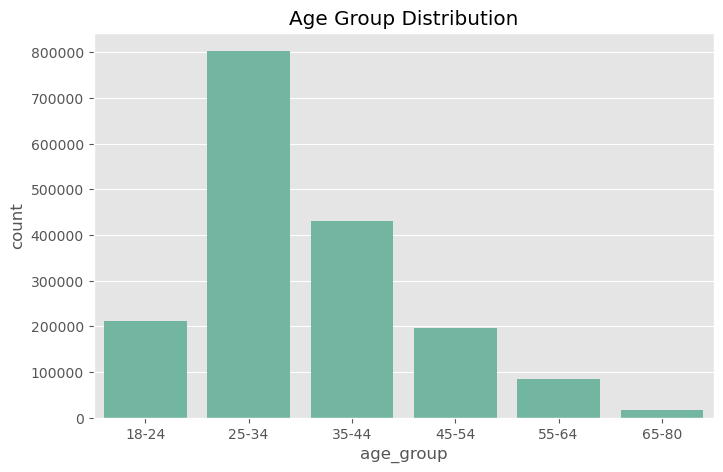

In [69]:
plt.figure(figsize=(8,5))

sns.countplot(
    data=bike_clean,
    x="age_group",
    order=labels
)

plt.title("Age Group Distribution")

plt.show()

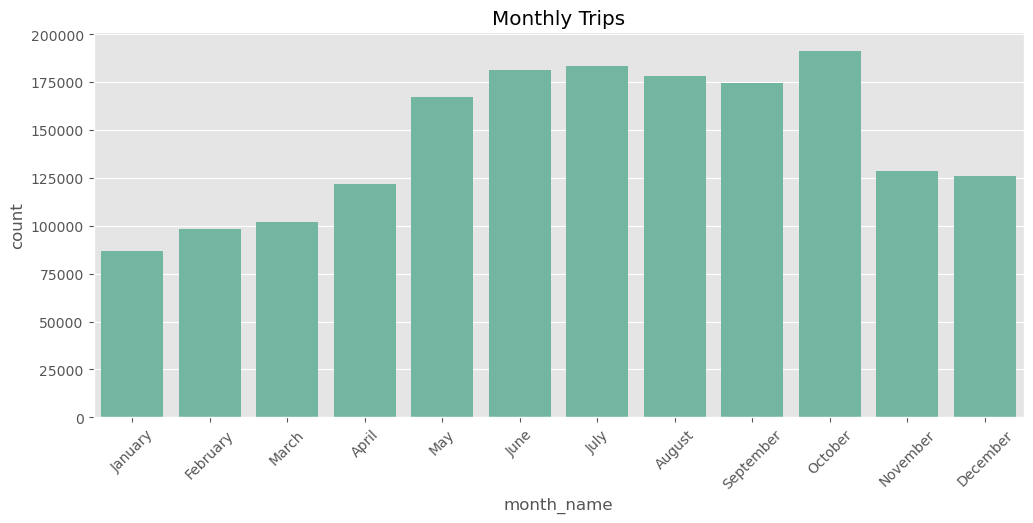

In [70]:
month_order = [
    "January","February","March","April",
    "May","June","July","August",
    "September","October","November","December"
]

plt.figure(figsize=(12,5))

sns.countplot(
    data=bike_clean,
    x="month_name",
    order=month_order
)

plt.xticks(rotation=45)

plt.title("Monthly Trips")

plt.show()

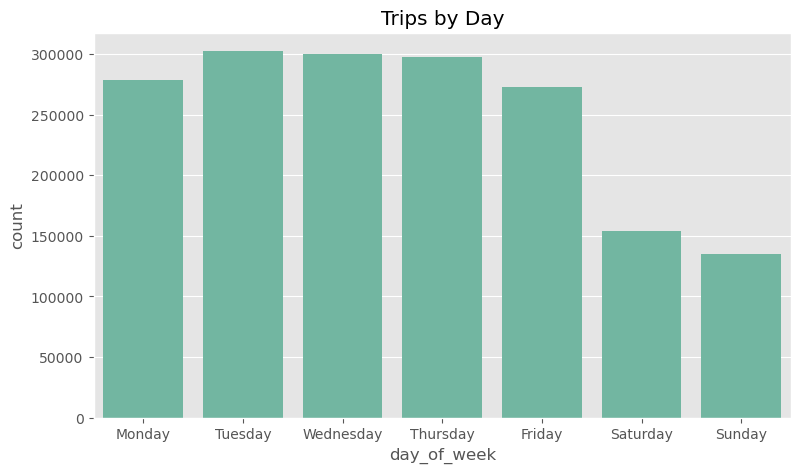

In [71]:
day_order = [
    "Monday","Tuesday","Wednesday",
    "Thursday","Friday",
    "Saturday","Sunday"
]

plt.figure(figsize=(9,5))

sns.countplot(
    data=bike_clean,
    x="day_of_week",
    order=day_order
)

plt.title("Trips by Day")

plt.show()

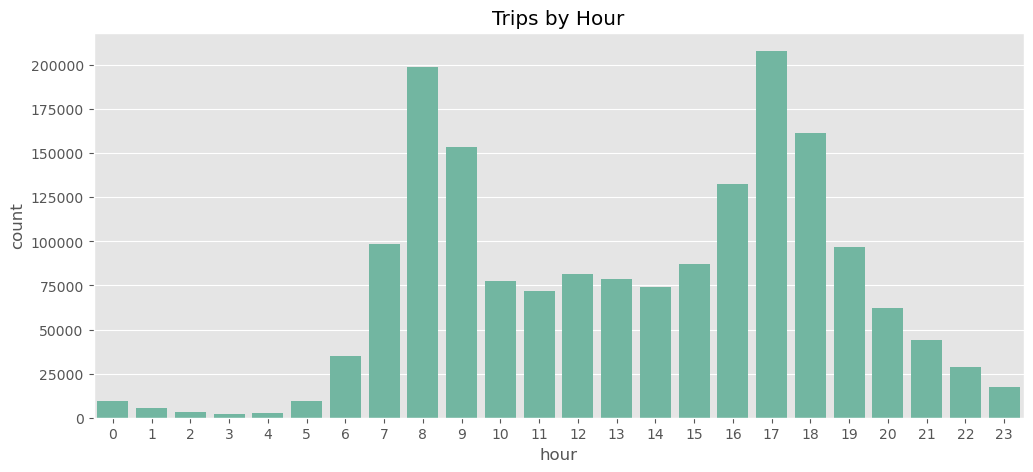

In [72]:
plt.figure(figsize=(12,5))

sns.countplot(
    data=bike_clean,
    x="hour"
)

plt.title("Trips by Hour")

plt.show()

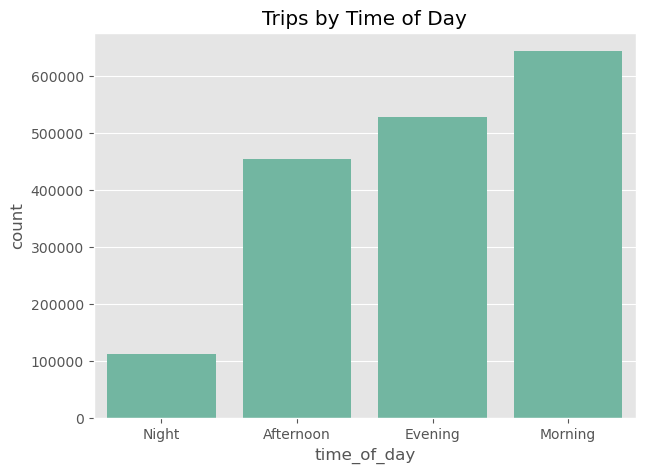

In [73]:
plt.figure(figsize=(7,5))

sns.countplot(
    data=bike_clean,
    x="time_of_day"
)

plt.title("Trips by Time of Day")

plt.show()

In [74]:
bike_clean["bike_share_for_all_trip"].value_counts()

bike_share_for_all_trip
No     1578797
Yes     160332
Name: count, dtype: int64

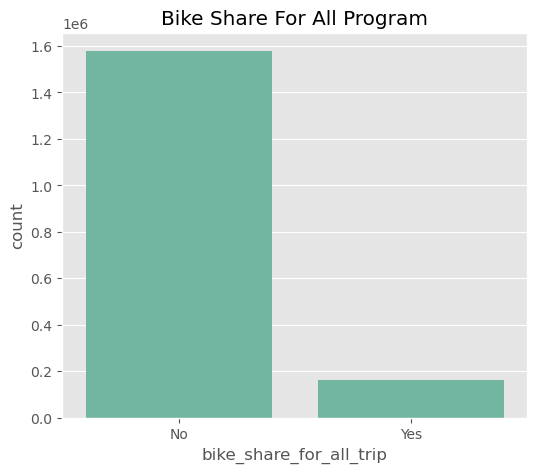

In [75]:
plt.figure(figsize=(6,5))

sns.countplot(
    data=bike_clean,
    x="bike_share_for_all_trip"
)

plt.title("Bike Share For All Program")

plt.show()

In [76]:
#bivariate analysis
bike_clean.groupby("user_type")["duration_min"].describe()

,count,mean,std,min,25%,50%,75%,max
user_type,,,,,,,,
Customer,199036.0,26.685982,71.746986,1.016667,9.166667,14.600000,23.566667,1436.800000
Subscriber,1540093.0,11.097449,22.170683,1.016667,5.500000,8.583333,13.033333,1438.016667


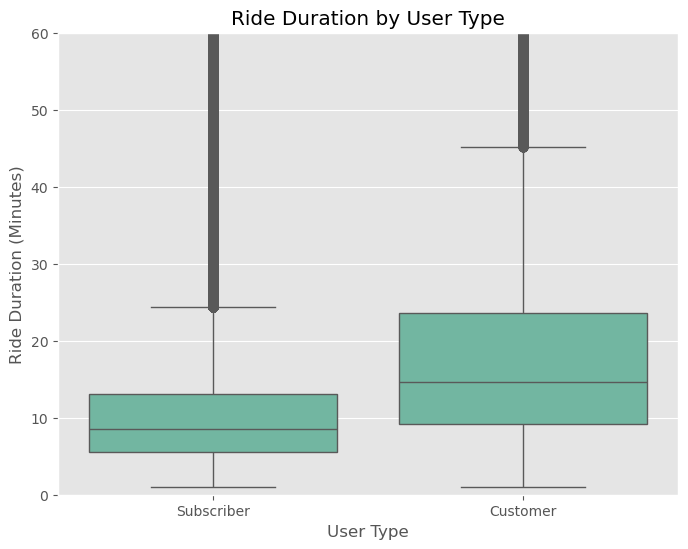

In [77]:
plt.figure(figsize=(8,6))

sns.boxplot(
    data=bike_clean,
    x="user_type",
    y="duration_min"
)

plt.ylim(0,60)

plt.title("Ride Duration by User Type")
plt.xlabel("User Type")
plt.ylabel("Ride Duration (Minutes)")

plt.show()

In [78]:
bike_clean.groupby("member_gender")["duration_min"].mean()

member_gender
Female    14.918053
Male      12.156993
Other     14.414858
Name: duration_min, dtype: float64

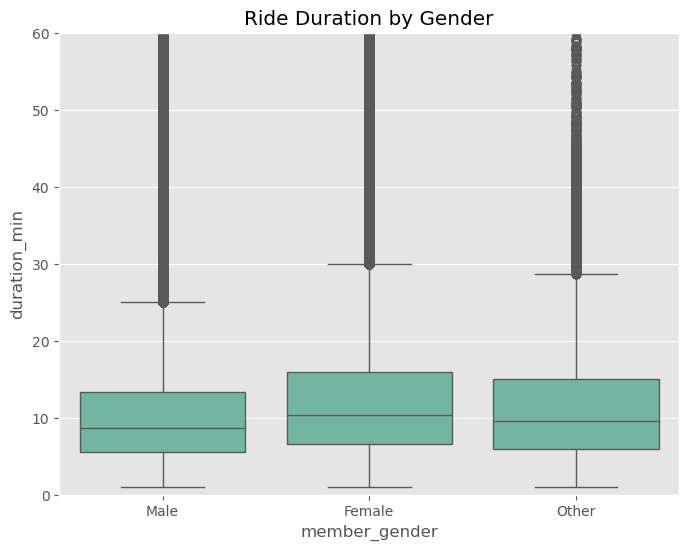

In [94]:
plt.figure(figsize=(8,6))

sns.boxplot(
    data=bike_clean,
    x="member_gender",
    y="duration_min"
)

plt.ylim(0,60)

plt.title("Ride Duration by Gender")

plt.show()

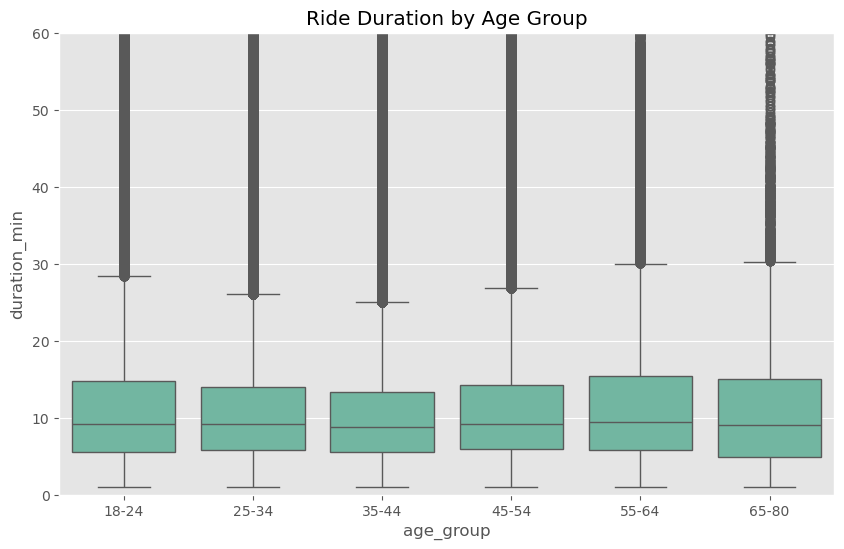

In [80]:
plt.figure(figsize=(10,6))

sns.boxplot(
    data=bike_clean,
    x="age_group",
    y="duration_min"
)

plt.ylim(0,60)

plt.title("Ride Duration by Age Group")

plt.show()

In [81]:
pd.crosstab(
    bike_clean["member_gender"],
    bike_clean["user_type"]
)

user_type,Customer,Subscriber
member_gender,,
Female,63153,371413
Male,131889,1146041
Other,3994,22639


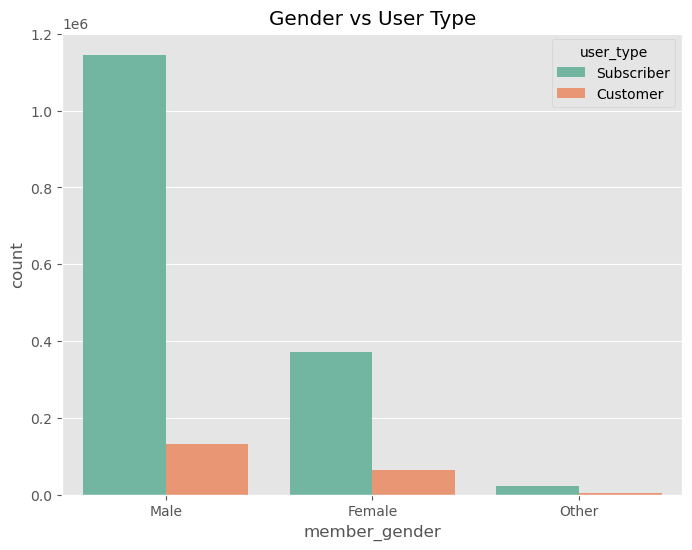

In [82]:
plt.figure(figsize=(8,6))

sns.countplot(
    data=bike_clean,
    x="member_gender",
    hue="user_type"
)

plt.title("Gender vs User Type")

plt.show()

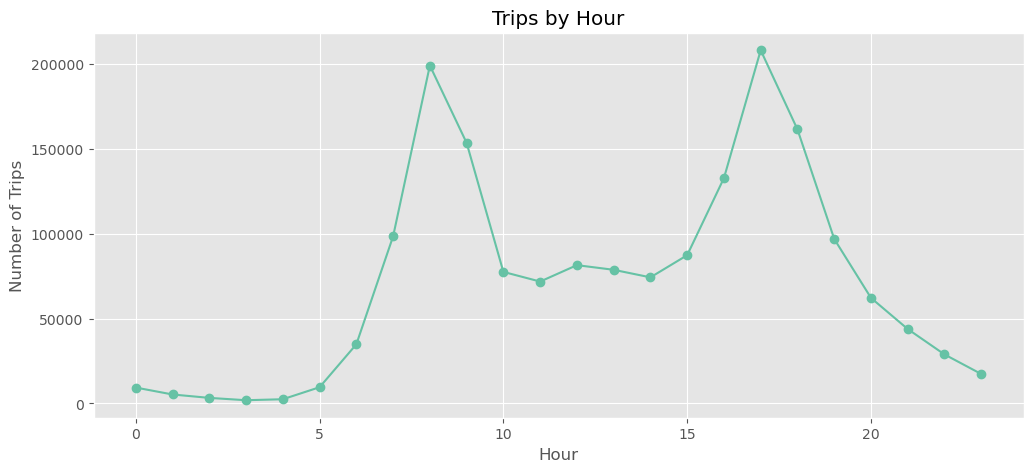

In [83]:
hourly = bike_clean.groupby("hour").size()

plt.figure(figsize=(12,5))

plt.plot(
    hourly.index,
    hourly.values,
    marker="o"
)

plt.title("Trips by Hour")
plt.xlabel("Hour")
plt.ylabel("Number of Trips")

plt.grid(True)

plt.show()

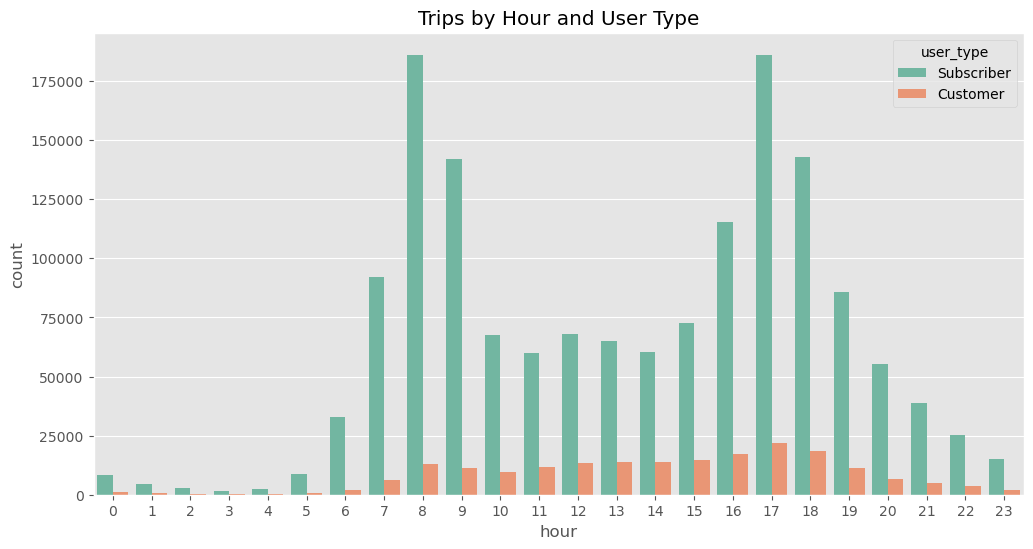

In [84]:
plt.figure(figsize=(12,6))

sns.countplot(
    data=bike_clean,
    x="hour",
    hue="user_type"
)

plt.title("Trips by Hour and User Type")

plt.show()

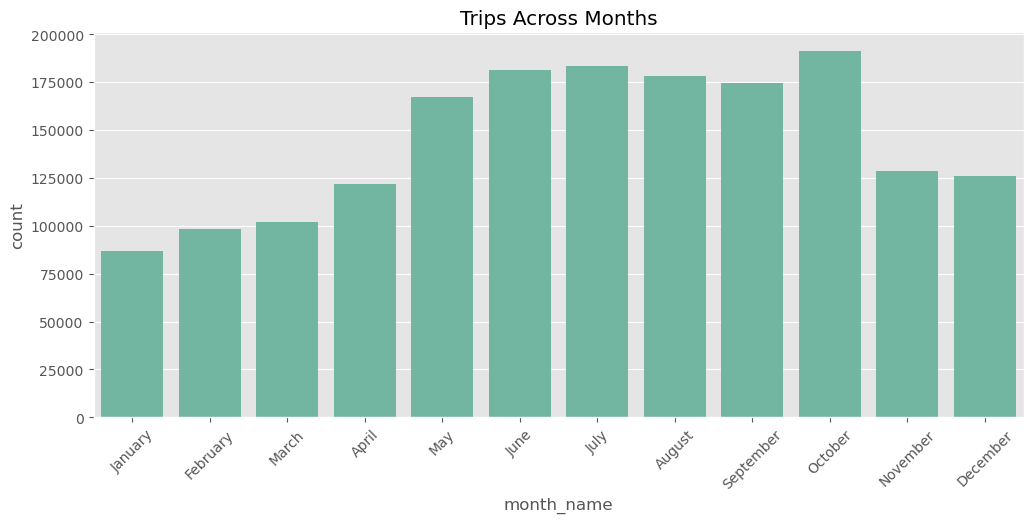

In [85]:
month_order = [
    "January","February","March","April",
    "May","June","July","August",
    "September","October","November","December"
]

plt.figure(figsize=(12,5))

sns.countplot(
    data=bike_clean,
    x="month_name",
    order=month_order
)

plt.xticks(rotation=45)

plt.title("Trips Across Months")

plt.show()

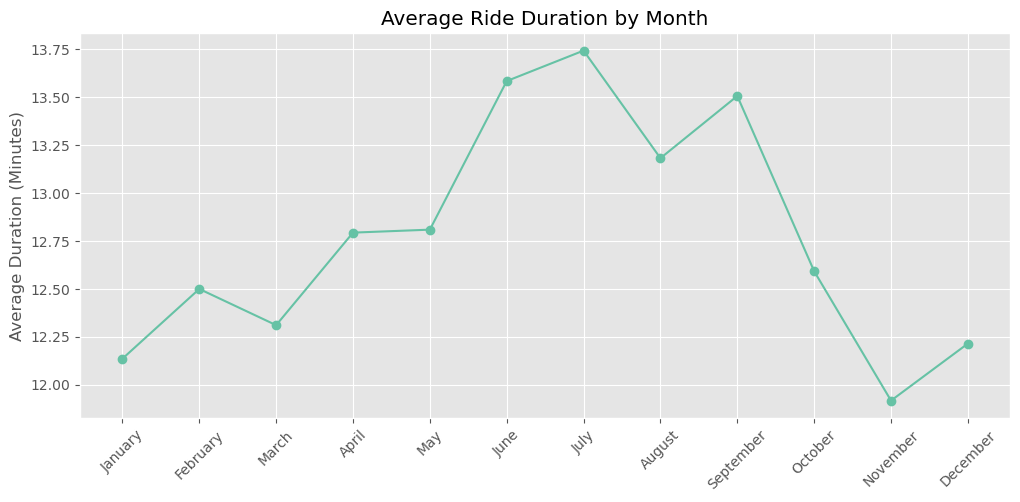

In [86]:
monthly = bike_clean.groupby("month_name")["duration_min"].mean().reindex(month_order)

plt.figure(figsize=(12,5))

plt.plot(
    monthly.index,
    monthly.values,
    marker="o"
)

plt.xticks(rotation=45)

plt.title("Average Ride Duration by Month")

plt.ylabel("Average Duration (Minutes)")

plt.show()

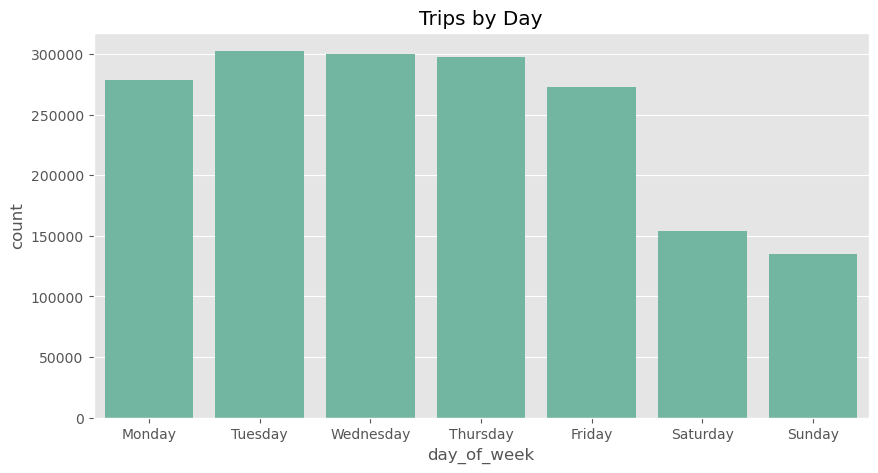

In [87]:
day_order = [
    "Monday","Tuesday","Wednesday",
    "Thursday","Friday",
    "Saturday","Sunday"
]

plt.figure(figsize=(10,5))

sns.countplot(
    data=bike_clean,
    x="day_of_week",
    order=day_order
)

plt.title("Trips by Day")

plt.show()

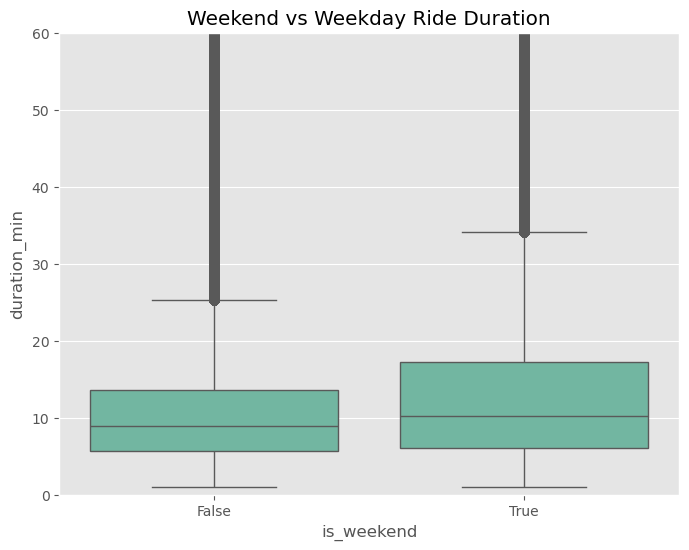

In [88]:
plt.figure(figsize=(8,6))

sns.boxplot(
    data=bike_clean,
    x="is_weekend",
    y="duration_min"
)

plt.ylim(0,60)

plt.title("Weekend vs Weekday Ride Duration")

plt.show()

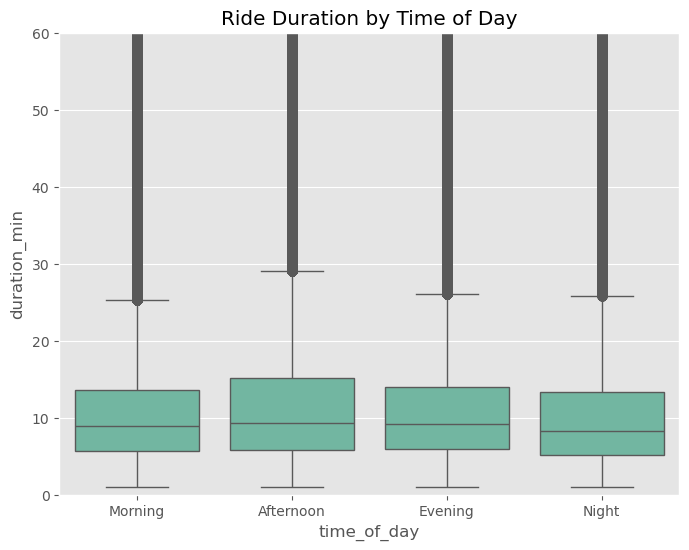

In [89]:
order = [
    "Morning",
    "Afternoon",
    "Evening",
    "Night"
]

plt.figure(figsize=(8,6))

sns.boxplot(
    data=bike_clean,
    x="time_of_day",
    y="duration_min",
    order=order
)

plt.ylim(0,60)

plt.title("Ride Duration by Time of Day")

plt.show()

In [90]:
numeric = bike_clean[
    [
        "duration_sec",
        "duration_min",
        "age",
        "bike_id"
    ]
]

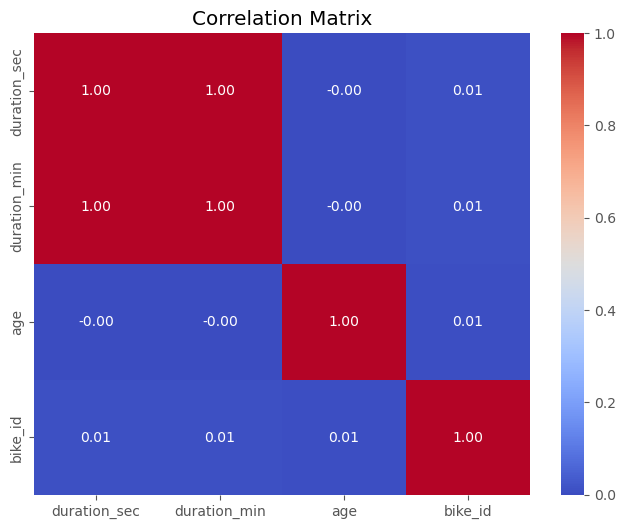

In [91]:
plt.figure(figsize=(8,6))

sns.heatmap(
    numeric.corr(),
    annot=True,
    cmap="coolwarm",
    fmt=".2f"
)

plt.title("Correlation Matrix")

plt.show()

<Axes: xlabel='hour', ylabel='count'>

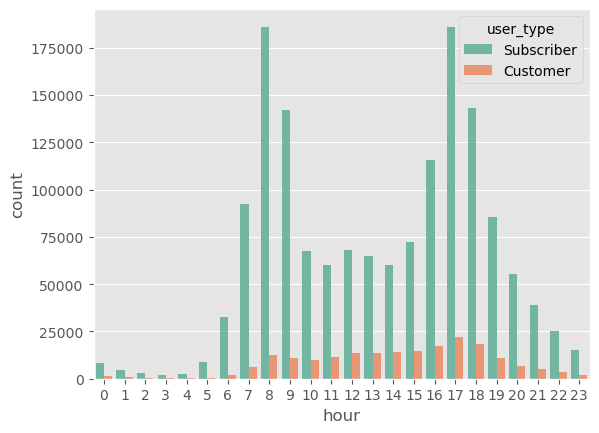

In [95]:
#multivariate analysis
sns.countplot(
    data=bike_clean,
    x="hour",
    hue="user_type"
)

(0.0, 60.0)

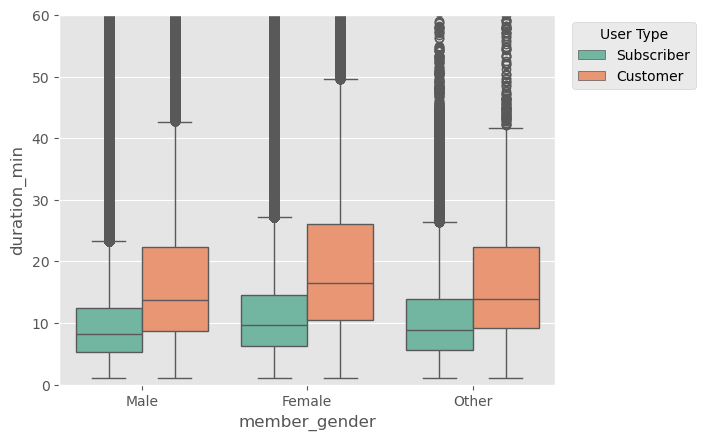

In [98]:
sns.boxplot(
    data=bike_clean,
    x="member_gender",
    y="duration_min",
    hue="user_type"
)
plt.legend(
    title="User Type",
    bbox_to_anchor=(1.02, 1),
    loc="upper left"
)

plt.ylim(0,60)

<Axes: xlabel='age_group', ylabel='count'>

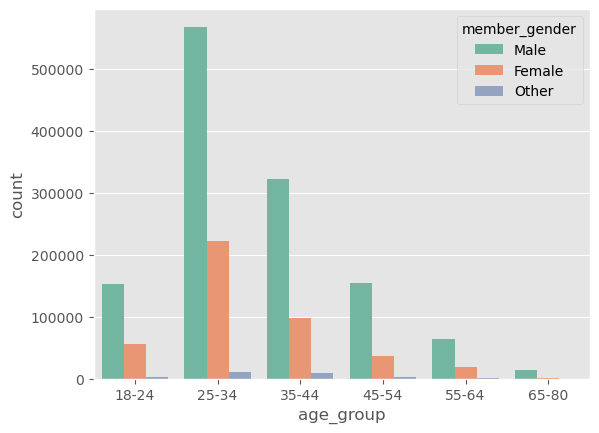

In [99]:
sns.countplot(
    data=bike_clean,
    x="age_group",
    hue="member_gender"
)

([0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11],
 [Text(0, 0, 'January'),
  Text(1, 0, 'February'),
  Text(2, 0, 'March'),
  Text(3, 0, 'April'),
  Text(4, 0, 'May'),
  Text(5, 0, 'June'),
  Text(6, 0, 'July'),
  Text(7, 0, 'August'),
  Text(8, 0, 'September'),
  Text(9, 0, 'October'),
  Text(10, 0, 'November'),
  Text(11, 0, 'December')])

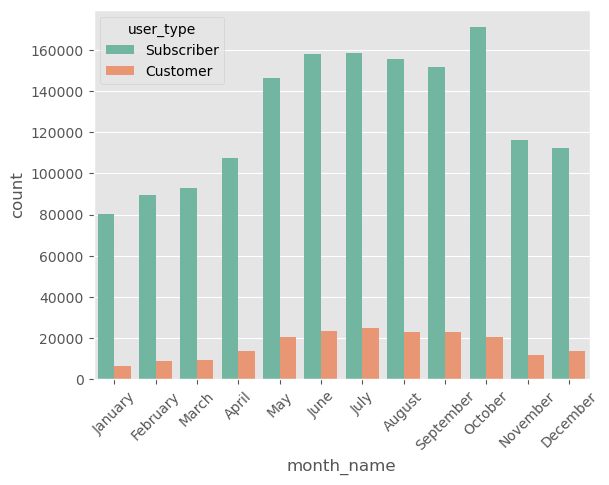

In [100]:
sns.countplot(
    data=bike_clean,
    x="month_name",
    hue="user_type",
    order=month_order
)

plt.xticks(rotation=45)

<Axes: xlabel='day_of_week', ylabel='count'>

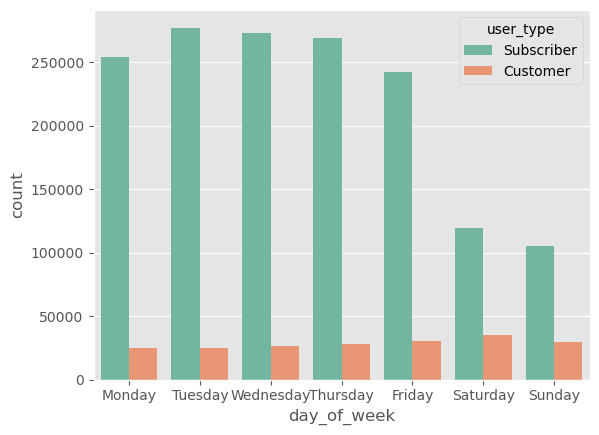

In [101]:
sns.countplot(
    data=bike_clean,
    x="day_of_week",
    hue="user_type",
    order=day_order
)

<Axes: xlabel='time_of_day', ylabel='count'>

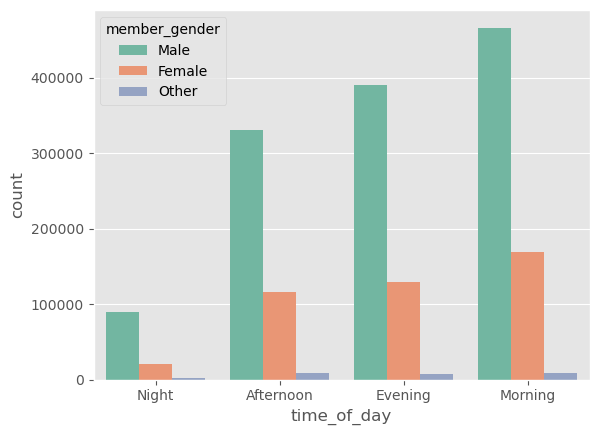

In [102]:
sns.countplot(
    data=bike_clean,
    x="time_of_day",
    hue="member_gender"
)

<Axes: xlabel='hour', ylabel='day_of_week'>

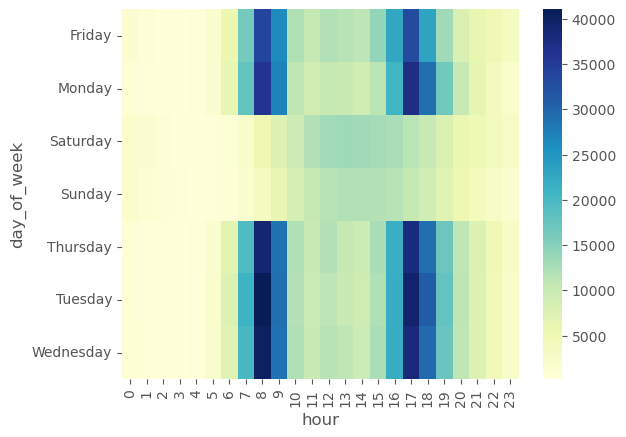

In [103]:
pivot = bike_clean.pivot_table(
    values="bike_id",
    index="day_of_week",
    columns="hour",
    aggfunc="count"
)

sns.heatmap(
    pivot,
    cmap="YlGnBu"
)